# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
from torch.nn import CosineSimilarity

import matplotlib.pyplot as plt

LANGS = ["ger", "fre", "rus", "zho", "ita", "ned", "vie"]

## Calculate KL divergence

In [35]:
def get_kl_divergences(df):
    """
    Calculate KL divergence between probability distributions for each sentence_id.
    
    For each sentence_id, we have a probability distribution over tokens (noun-fre, adj-fre, etc.).
    We calculate KL(plant_dist || base_dist) for each sentence.
    """
    kl_divergences = []
    
    for sentence_id in df['sentence_id'].unique():
        sentence_data = df[df['sentence_id'] == sentence_id]
        
        # Calculate KL divergence: sum of prob_plant * log(prob_plant / prob_base)
        kl = (sentence_data['prob_plant'] * np.log(sentence_data['prob_plant'] / sentence_data['prob_base'])).sum()
        
        kl_divergences.append({'sentence_id': sentence_id, 'kl_divergence': kl})
    
    result = pd.DataFrame(kl_divergences)
    return result

In [49]:
# Example usage: load your CSV file and calculate mean KL divergence
# df = pd.read_csv('your_data.csv')
# mean_kl = get_kl_divergence(df)
# print(mean_kl)

# tgt_lang_base = "zho"

kl_div_grid = torch.zeros([len(LANGS), len(LANGS)])

# Or with the provided example data:
for i, tgt_lang_base in enumerate(LANGS):
    for j, tgt_lang_plant in enumerate(LANGS):
        if tgt_lang_base == tgt_lang_plant:
            continue
        data = pd.read_csv(f'/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/probs/noun-adj_mgpt_eng-{tgt_lang_base}_eng-{tgt_lang_plant}_layer11_head2.csv')
        df = pd.DataFrame(data)
        result = get_kl_divergences(df)['kl_divergence'].mean()
        kl_div_grid[i, j] = result

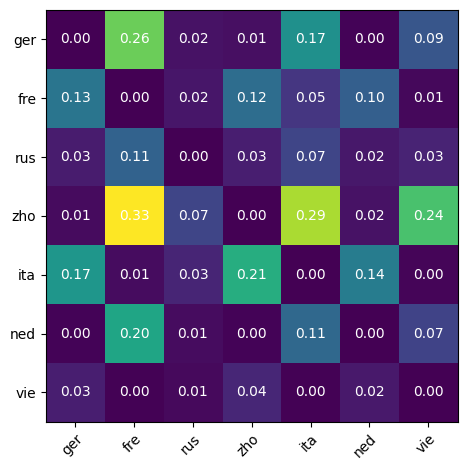

In [50]:
fig, ax = plt.subplots()
im = ax.imshow(kl_div_grid)

ax.set_xticks(range(len(LANGS)), labels=LANGS,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(LANGS)), labels=LANGS)

# Loop over data dimensions and create text annotations.
for i in range(len(LANGS)):
    for j in range(len(LANGS)):
        text = ax.text(j, i, "%.2f" % kl_div_grid[i, j].item(),
                       ha="center", va="center", color="w")

fig.tight_layout()
plt.show()

In [41]:
data.head()

,Unnamed: 0,sentence_id,token_type,token,prob_base,prob_plant,type
0,0,0,adj-zho,白,0.957012,0.864144,head_attention_value_output
1,1,0,noun-zho,山,0.042988,0.135856,head_attention_value_output
2,2,1,adj-zho,響,0.854250,0.660117,head_attention_value_output
3,3,1,noun-zho,鐘,0.145750,0.339883,head_attention_value_output
4,4,2,adj-zho,白,0.980690,0.843625,head_attention_value_output


## Plot activations

In [21]:
lang2mean_activation = {}
for lang in LANGS:
    act_path = f"/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/activations/aya-expanse-8b_eng-{lang}_layer15_head0.pt"
    lang2mean_activation[lang] = torch.load(act_path)

In [22]:
lang2mean_activation['ger'].shape

torch.Size([1, 1, 1, 128])

In [23]:
cos_sim = CosineSimilarity(dim=-1)

In [24]:
lang_similarity_grid = torch.zeros([len(LANGS), len(LANGS)])

for i, i_lang in enumerate(LANGS):
    for j, j_lang in enumerate(LANGS):
        lang_similarity_grid[i, j] = cos_sim(lang2mean_activation[i_lang], lang2mean_activation[j_lang]).item()

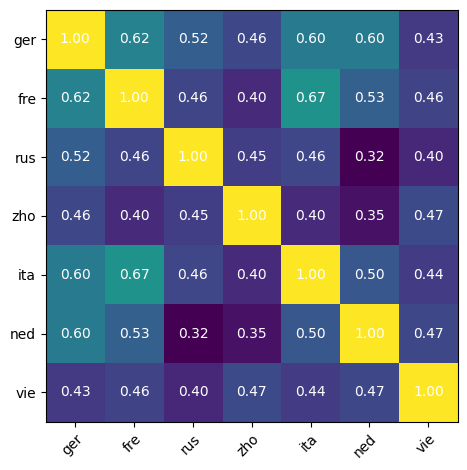

In [25]:
fig, ax = plt.subplots()
im = ax.imshow(lang_similarity_grid)

ax.set_xticks(range(len(LANGS)), labels=LANGS,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(LANGS)), labels=LANGS)

# Loop over data dimensions and create text annotations.
for i in range(len(LANGS)):
    for j in range(len(LANGS)):
        text = ax.text(j, i, "%.2f" % lang_similarity_grid[i, j].item(),
                       ha="center", va="center", color="w")

fig.tight_layout()
plt.show()